# Task 3 — Customer Churn Prediction (Bank Customers)

## Objective
Predict which customers are likely to leave the bank (churn).

## Deliverables
- Data cleaning + preparation
- Encoding categorical features (Geography, Gender)
- Train a classification model
- Evaluate performance (accuracy + confusion matrix)
- Feature importance analysis (what drives churn)

## How to run
Run notebook cells **top-to-bottom** (Run All).
Put dataset file in: `data/Churn_Modelling.csv` (or update path in Setup cell).

In [9]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ----------------------------
# Config
# ----------------------------
DATA_PATH = Path("../data/Churn_Modelling.csv")   # change file name here if needed
TARGET_CANDIDATES = ["exited", "churn", "churned", "target", "label", "y"]

TEST_SIZE = 0.20
RANDOM_STATE = 42

FIG_DIR = Path("../outputs/task3_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Helpers
# ----------------------------
def save_fig(filename: str) -> None:
    """Save current matplotlib figure safely."""
    try:
        out = FIG_DIR / filename
        plt.tight_layout()
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print("Saved:", out)
    except Exception as e:
        print("Note: could not save figure:", e)

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize columns for consistency across dataset versions."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[ \-./]", "_", regex=True)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return df

def read_csv_safely(path: Path) -> pd.DataFrame:
    """Read CSV with auto-separator detection (handles comma/semicolon)."""
    return pd.read_csv(path, sep=None, engine="python")

print("Setup complete.")
print("Looking for dataset at:", DATA_PATH.resolve())

Setup complete.
Looking for dataset at: F:\coding\DevelopersHub-DS-Internship-Tasks\data\Churn_Modelling.csv


In [10]:
READY = True

if not DATA_PATH.exists():
    READY = False
    print("Dataset not found.")
    print("Fix: Put file in data/ or update DATA_PATH in Setup cell.")
else:
    df_raw = read_csv_safely(DATA_PATH)
    df = normalize_columns(df_raw)

    print("Loaded successfully.")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())

    target_col = next((c for c in TARGET_CANDIDATES if c in df.columns), None)
    if target_col is None:
        READY = False
        print("Target column not found.")
        print("Available columns:", df.columns.tolist())
        print("Fix: Add your target column name to TARGET_CANDIDATES in Setup cell.")
    else:
        print("Target column selected:", target_col)
        print("Target unique values:", df[target_col].dropna().unique())

Loaded successfully.
Shape: (10000, 14)
Columns: ['rownumber', 'customerid', 'surname', 'creditscore', 'geography', 'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard', 'isactivemember', 'estimatedsalary', 'exited']


,rownumber,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Target column selected: exited
Target unique values: [1 0]


In [11]:
if not READY:
    print("Skipping: dataset/target not ready.")
else:
    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
    display(missing_pct[missing_pct > 0].to_frame("missing_%"))

    print("Duplicate rows:", int(df.duplicated().sum()))

    # churn rate (works if numeric 0/1)
    if pd.api.types.is_numeric_dtype(df[target_col]):
        print("Churn rate:", round(float(df[target_col].mean()), 4))
    else:
        print("Target is not numeric; churn rate mean not computed.")

,missing_%


Duplicate rows: 0
Churn rate: 0.2037


## EDA (Quick Business View)

We will plot churn vs:
- Geography
- Gender
- IsActiveMember
and a numeric distribution:
- Age by churn

Plots are safe: if a column is missing, it will be skipped.

Saved: ..\outputs\task3_figures\count_geography_by_exited.png


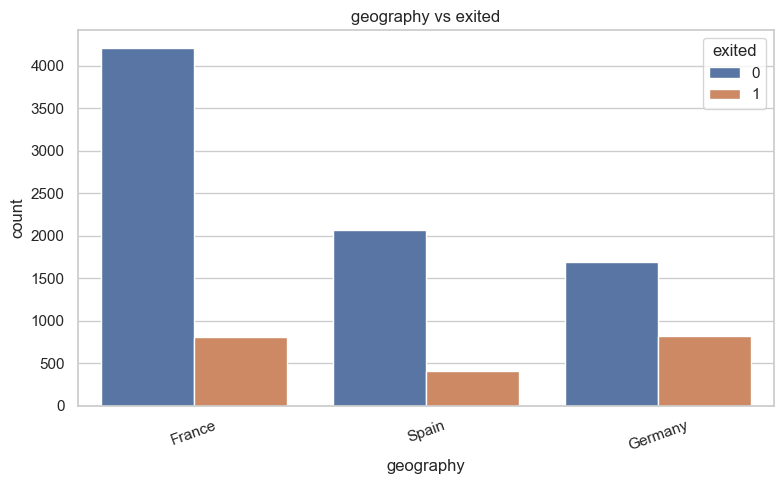

Saved: ..\outputs\task3_figures\count_gender_by_exited.png


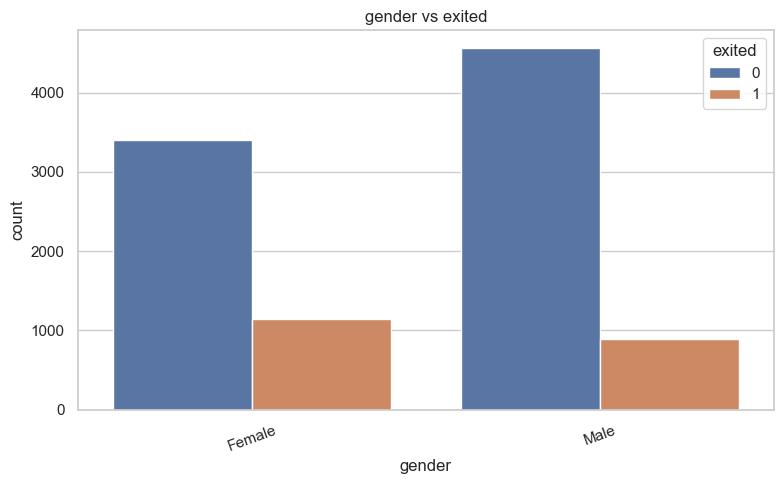

Saved: ..\outputs\task3_figures\count_isactivemember_by_exited.png


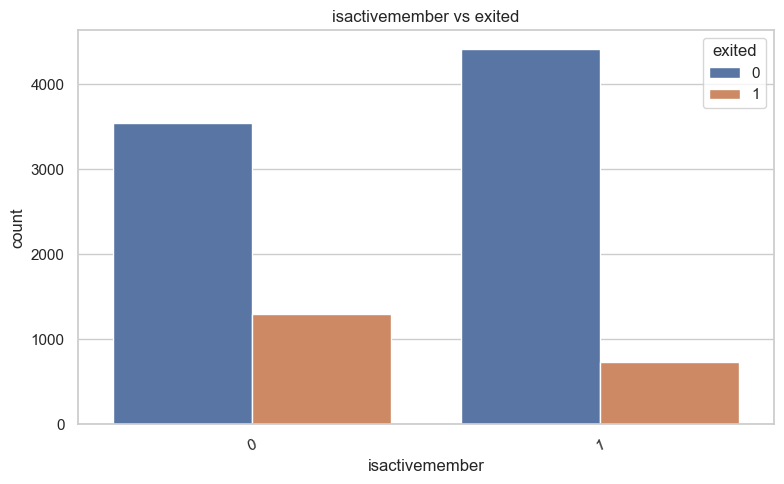

Saved: ..\outputs\task3_figures\hist_age_by_exited.png


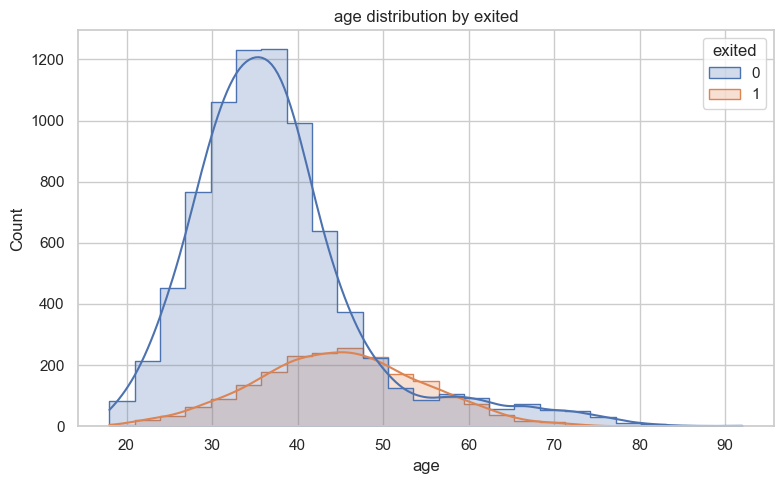

In [12]:
if not READY:
    print("Skipping EDA: dataset/target not ready.")
else:
    def safe_countplot(col: str):
        if col not in df.columns:
            print(f"Skipped countplot: '{col}' not found.")
            return
        ax = sns.countplot(data=df, x=col, hue=target_col)
        ax.set_title(f"{col} vs {target_col}")
        plt.xticks(rotation=20)
        save_fig(f"count_{col}_by_{target_col}.png")
        plt.show()

    def safe_hist_by_target(col: str, bins: int = 25):
        if col not in df.columns:
            print(f"Skipped hist: '{col}' not found.")
            return
        ax = sns.histplot(data=df, x=col, hue=target_col, bins=bins, kde=True, element="step")
        ax.set_title(f"{col} distribution by {target_col}")
        save_fig(f"hist_{col}_by_{target_col}.png")
        plt.show()

    safe_countplot("geography")
    safe_countplot("gender")
    safe_countplot("isactivemember")
    safe_hist_by_target("age")

In [13]:
if not READY:
    print("Skipping modeling: dataset/target not ready.")
else:
    # Drop common ID-like columns if present
    drop_cols = [c for c in ["rownumber", "customerid", "surname"] if c in df.columns]
    df_model = df.drop(columns=drop_cols).copy()

    # Prepare y
    y_raw = df_model[target_col]
    if pd.api.types.is_numeric_dtype(y_raw):
        y = y_raw.astype(int)
    else:
        # safe mapping for yes/no style
        y_map = {"yes": 1, "no": 0, "y": 1, "n": 0, "true": 1, "false": 0}
        y = y_raw.astype(str).str.strip().str.lower().map(y_map)

        if y.isna().any():
            codes, uniques = pd.factorize(y_raw.astype(str))
            y = pd.Series(codes, index=y_raw.index)
            print("Target factorized. Classes:", list(uniques))

    X = df_model.drop(columns=[target_col])

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
        ],
        remainder="drop"
    )

    model = RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )

    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() == 2 else None
    )

    clf.fit(X_train, y_train)
    print("Model trained.")
    print("Dropped columns:", drop_cols)
    print("Numeric:", len(num_cols), "| Categorical:", len(cat_cols))

Model trained.
Dropped columns: ['rownumber', 'customerid', 'surname']
Numeric: 8 | Categorical: 2


Test Accuracy: 0.8615

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

Saved: ..\outputs\task3_figures\confusion_matrix.png


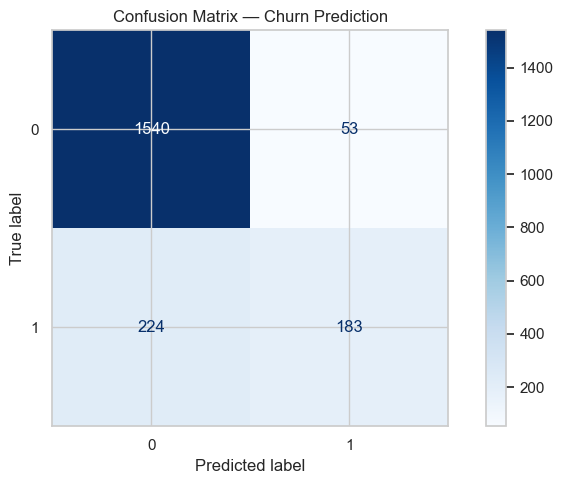

In [14]:
if not READY:
    print("Skipping evaluation: model not ready.")
else:
    pred = clf.predict(X_test)

    print("Test Accuracy:", round(accuracy_score(y_test, pred), 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Confusion Matrix — Churn Prediction")
    save_fig("confusion_matrix.png")
    plt.show()

,feature,importance
0,age,0.251173
1,balance,0.140337
2,estimatedsalary,0.139197
3,creditscore,0.134175
4,numofproducts,0.127892
5,tenure,0.082924
6,isactivemember,0.035852
7,geography_Germany,0.026172
8,hascrcard,0.018185
9,geography_France,0.012593


Saved: ..\outputs\task3_figures\top_feature_importances.png


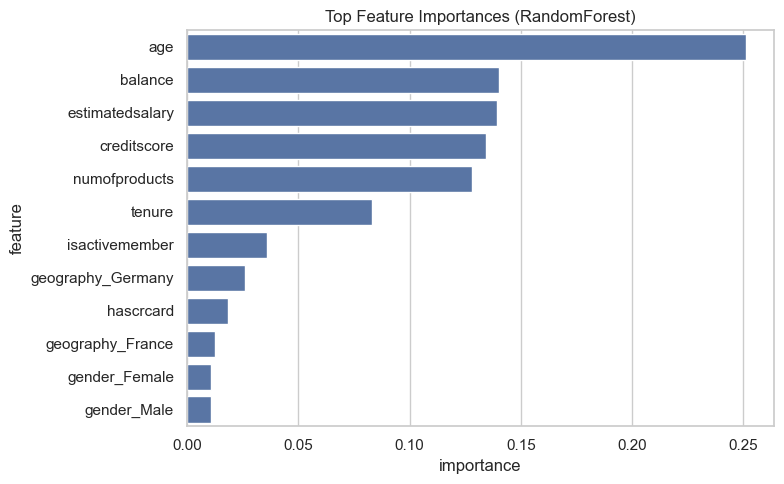

In [15]:
if not READY:
    print("Skipping feature importance: model not ready.")
else:
    try:
        ohe = clf.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
        cat_feature_names = ohe.get_feature_names_out(cat_cols)
        feature_names = np.array(num_cols + list(cat_feature_names))

        importances = clf.named_steps["model"].feature_importances_

        fi = (pd.DataFrame({"feature": feature_names, "importance": importances})
              .sort_values("importance", ascending=False)
              .reset_index(drop=True))

        display(fi.head(20))

        ax = sns.barplot(data=fi.head(12), x="importance", y="feature")
        ax.set_title("Top Feature Importances (RandomForest)")
        save_fig("top_feature_importances.png")
        plt.show()

    except Exception as e:
        print("Feature importance skipped. Reason:", e)

In [16]:
if not READY:
    print("Skipping CV: model not ready.")
else:
    if y.nunique() == 2:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
        print("CV Accuracy mean:", round(scores.mean(), 4), "| std:", round(scores.std(), 4))
    else:
        print("CV skipped: target is not binary.")

CV Accuracy mean: 0.8595 | std: 0.0065


## Conclusion
- Report test accuracy and confusion matrix observations.
- Mention top 3–5 features from feature importance.
- Give 2 business recommendations (retention strategy, targeted offers, improve engagement for inactive users).